In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
df=pd.read_csv('housing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [36]:
df.isna().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [37]:
df.dtypes

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object

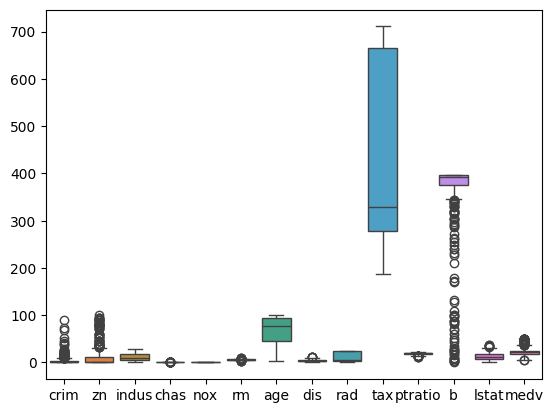

In [38]:
sns.boxplot(data=df)
plt.show()

In [66]:
def remove_outliers(df,col):
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    IQR=q3-q1
    lb=q1-IQR*1.5
    ub=q3+IQR*1.5
    df[col]=np.where(df[col]<lb,lb,df[col])
    df[col]=np.where(df[col]>ub,ub,df[col])
    return df
for col in df.columns:
    df=remove_outliers(df,col)
    

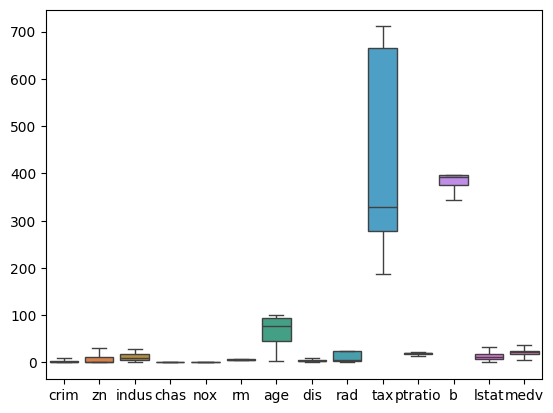

In [67]:
sns.boxplot(data=df)
plt.show()

In [68]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [69]:
X=df.drop('medv',axis=1)
y=df['medv']

In [60]:
print(y)

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: medv, Length: 506, dtype: float64


In [70]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)


In [71]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print(X_test_scaled)

[[-0.65082905 -0.58379113  0.10915931 ...  1.17955501  0.61182844
  -0.88311604]
 [-0.4525654   1.07319748 -1.05275937 ... -2.4570889   0.5567563
  -0.30387981]
 [-0.65978395 -0.58379113 -0.7622797  ...  0.34032949  0.79277974
  -0.5489974 ]
 ...
 [ 2.07366515 -0.58379113  1.00979226 ...  0.80656589  0.79277974
   1.62788032]
 [-0.65062228  1.48744464 -0.88343454 ...  0.57344769  0.79277974
  -0.8466402 ]
 [-0.64426719 -0.58379113 -0.38275852 ...  1.13293137  0.30971844
   0.22720833]]


In [75]:
class linear_reg:
    def __init__(self,epoch=1000,learning_rate=0.001):
        self.lr=learning_rate
        self.epoch=epoch
        self.weights=None
        self.bias=None

    def fit(self,X,y):
        n_sample,n_feature=X.shape
        self.weights=np.zeros(n_feature)
        self.bias=0;
        for _ in range(self.epoch):
            y_pred=np.dot(X,self.weights)+self.bias
            error=y_pred-y
            dw=(1 / n_sample) * np.dot(X.T, error)
            db=np.mean(error)
            self.weights-=self.lr*dw
            self.bias-=self.lr*db

    def predict(self,X):
        return np.dot(X,self.weights)+self.bias


In [76]:
model=linear_reg(epoch=1000,learning_rate=0.001)
model.fit(X_train_scaled,y_train)

In [77]:
y_predicted=model.predict(X_test_scaled)
print(y_predicted)

[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]


In [47]:
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score
print("Linear regression r2Score",r2_score(y_test,y_predicted))
print("Linear regression mean squred error",np.sqrt(mean_squared_error(y_test,y_predicted)))

ValueError: Input contains NaN.